### Скачивание данных

In [ ]:
!mkdir -p data/images

!wget -O /tmp/isic2020_train.zip https://isic-archive.s3.amazonaws.com/challenges/2020/ISIC_2020_Training_JPEG.zip
!unzip -q -j /tmp/isic2020_train.zip "*.jpg" -d data/images
!rm /tmp/isic2020_train.zip

!wget -O /tmp/isic2019_train.zip https://isic-archive.s3.amazonaws.com/challenges/2019/ISIC_2019_Training_Input.zip
!unzip -q -j /tmp/isic2019_train.zip "*.jpg" -d data/images
!rm /tmp/isic2019_train.zip

!wget -O /tmp/isic2019_test.zip https://isic-archive.s3.amazonaws.com/challenges/2019/ISIC_2019_Test_Input.zip
!unzip -q -n -j /tmp/isic2019_test.zip "*.jpg" -d data/images
!rm /tmp/isic2019_test.zip

In [2]:
!wget https://isic-archive.s3.amazonaws.com/challenges/2019/ISIC_2019_Training_GroundTruth.csv
!wget https://isic-archive.s3.amazonaws.com/challenges/2019/ISIC_2019_Test_GroundTruth.csv
!wget https://isic-archive.s3.amazonaws.com/challenges/2020/ISIC_2020_Training_GroundTruth.csv

--2026-06-15 00:51:44--  https://isic-archive.s3.amazonaws.com/challenges/2019/ISIC_2019_Training_GroundTruth.csv
Resolving isic-archive.s3.amazonaws.com (isic-archive.s3.amazonaws.com)... 52.217.50.44, 52.216.216.41, 16.15.183.112, ...
Connecting to isic-archive.s3.amazonaws.com (isic-archive.s3.amazonaws.com)|52.217.50.44|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1291479 (1.2M) [text/csv]
Saving to: ‘ISIC_2019_Training_GroundTruth.csv’

ISIC_2019_Training_ 100%[===================>]   1.23M  --.-KB/s    in 0.1s    

2026-06-15 00:51:44 (12.8 MB/s) - ‘ISIC_2019_Training_GroundTruth.csv’ saved [1291479/1291479]

--2026-06-15 00:51:44--  https://isic-archive.s3.amazonaws.com/challenges/2019/ISIC_2019_Test_GroundTruth.csv
Resolving isic-archive.s3.amazonaws.com (isic-archive.s3.amazonaws.com)... 52.217.50.44, 52.216.216.41, 16.15.183.112, ...
Connecting to isic-archive.s3.amazonaws.com (isic-archive.s3.amazonaws.com)|52.217.50.44|:443... connected.
HTTP re

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import tqdm
import os
from IPython.display import clear_output
from typing import Optional, Dict, List

import torch.utils.data as data
import torchvision.transforms.v2 as v2
import torch
import torch.nn as nn
from torchinfo import summary
from PIL import Image

import wandb
import json
import random

from multiprocessing import Pool
import cv2

sns.set_theme(context="notebook", palette="muted")
RANDOM_STATE = 33

In [ ]:
def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    return seed

In [7]:
def resize_one_cv2(img_path):
    img = cv2.imread(f'data/images/{img_path}')
    if img is None:
        return img_path, 'failed to read'

    img = cv2.resize(img, (224, 224))
    cv2.imwrite(f'data/images/{img_path}', img)

image_paths = os.listdir('data/images')
with Pool(12) as pool:
    list(tqdm.tqdm(pool.imap_unordered(resize_one_cv2, image_paths), total=len(image_paths)))

100%|██████████| 66695/66695 [06:18<00:00, 175.99it/s]


In [7]:
labels = pd.read_parquet('meta_and_target.parquet')
labels['stratify_col'] = labels['source'].astype(str) + '_' + labels['target'].astype(str)

### Класс датасета

In [8]:
class ISICDataset(data.Dataset):
    def __init__(self, root, labels, transforms):
        super().__init__()
        self.transforms = transforms
        self.files = [root + '/' + fname + '.jpg' for fname in labels['image'].tolist()]
        self.targets = labels['target'].tolist()

    def __len__(self):
        return len(self.files)

    def __getitem__(self, index):
        fname = self.files[index]
        with Image.open(fname) as im:
            im = im.convert('RGB')

        if self.transforms:
            im = self.transforms(im)

        return im, self.targets[index]

### Функции для обучения

In [9]:
def training_epoch(model : nn.Module, optimizer : torch.optim.Optimizer, criterion : nn.Module, train_loader : data.DataLoader, device : torch.device, scheduler=None, tqdm_desc='Train'):
    model.train()

    loss_sum = 0.0
    n_samples = 0

    all_probs = []
    all_targets = []

    pbar = tqdm.tqdm(train_loader, desc=tqdm_desc)
    for x, y in pbar:
        x = x.to(device, non_blocking=True).float()
        y = y.to(device, non_blocking=True).float()

        optimizer.zero_grad()

        with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
            logits = model(x).squeeze(1)
            loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        if scheduler is not None:
            scheduler.step()

        bs = x.size(0)
        loss_sum += float(loss.item()) * bs
        n_samples += bs

        all_targets.extend(y.cpu().detach().numpy().flatten().tolist())
        all_probs.extend(logits.sigmoid().float().cpu().detach().numpy().flatten().tolist())

        avg_loss = loss_sum / max(1, n_samples)

        pbar.set_postfix({'loss': f'{avg_loss:.4f}', 'lr': f'{optimizer.param_groups[0]["lr"]:.2e}'})

    return {'loss' : loss_sum / max(1, n_samples), 'roc_auc' : roc_auc_score(all_targets, all_probs)}


@torch.no_grad()
def validation_epoch(model : nn.Module, criterion : nn.Module, valid_loader : data.DataLoader, device : torch.device, tqdm_desc='Valid'):
    model.eval()

    loss_sum = 0.0
    n_samples = 0

    all_probs = []
    all_targets = []

    pbar = tqdm.tqdm(valid_loader, desc=tqdm_desc)
    for x, y in pbar:
        x = x.to(device, non_blocking=True).float()
        y = y.to(device, non_blocking=True).float()

        with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
            logits = model(x).squeeze(1)
            loss = criterion(logits, y)

        bs = x.size(0)
        loss_sum += float(loss.item()) * bs
        n_samples += bs

        all_targets.extend(y.cpu().detach().numpy().flatten().tolist())
        all_probs.extend(logits.float().sigmoid().cpu().detach().numpy().flatten().tolist())

        avg_loss = loss_sum / max(1, n_samples)

        pbar.set_postfix({'loss': f'{avg_loss:.4f}'})


    return {'loss' : loss_sum / max(1, n_samples), 'roc_auc' : roc_auc_score(all_targets, all_probs)}

def plot_metrics(train_losses, val_losses, train_auc_roc, val_auc_roc):
    clear_output(True)
    epochs = np.arange(1, len(train_losses) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label='Train Loss', marker='o')
    plt.plot(epochs, val_losses, label='Val Loss', marker='o')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss Dynamics')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_auc_roc, label='Train AUC-ROC', marker='o')
    plt.plot(epochs, val_auc_roc, label='Val AUC-ROC', marker='o')
    plt.xlabel('Epoch')
    plt.ylabel('AUC-ROC')
    plt.title('AUC-ROC Dynamics')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.ylim([-0.05, 1.05])
    plt.legend()

    plt.tight_layout()
    plt.show()

def save_checkpoint(path: str, model: nn.Module, optimizer: torch.optim.Optimizer, epoch: int, val_loss : float) -> None:
    os.makedirs(os.path.dirname(path), exist_ok=True)
    torch.save({'epoch': epoch, 'val_loss': val_loss, 'model_state': model.state_dict(), 'optimizer_state': optimizer.state_dict()}, path)

def fit(model : nn.Module, train_loader : data.DataLoader, val_loader : data.DataLoader, optimizer : torch.optim.Optimizer, scheduler, criterion : nn.Module, device : torch.device, num_epochs: int, out_dir: str = None, plot_fn=None, use_wandb: bool = False, wandb_project: str = None, wandb_run_name: Optional[str] = None, wandb_config: Optional[dict] = None, save_every_n_epochs : int = 1) -> Dict[str, List[float]]:
    model.to(device)

    history = {
        'train_loss': [],
        'val_loss': [],
        'train_roc_auc' : [],
        'val_roc_auc' : [],
        'lr' : [],
    }

    best_roc_auc = 0

    run = None
    if use_wandb:
        run = wandb.init(project=wandb_project, name=wandb_run_name, config=wandb_config if wandb_config else {}, reinit='create_new')
        run.config.update({'num_params': sum(p.numel() for p in model.parameters()), 'device': str(device)}, allow_val_change=True)

    for epoch in range(1, num_epochs + 1):
        tr = training_epoch(model=model, train_loader=train_loader, optimizer=optimizer, scheduler=scheduler, criterion=criterion, device=device, tqdm_desc=f'Train {epoch}/{num_epochs}')
        va = validation_epoch(model=model, valid_loader=val_loader, criterion=criterion, device=device, tqdm_desc=f'Valid {epoch}/{num_epochs}')

        current_lr = optimizer.param_groups[0]['lr']

        history['train_loss'].append(tr['loss'])
        history['train_roc_auc'].append(tr['roc_auc'])
        history['val_loss'].append(va['loss'])
        history['val_roc_auc'].append(va['roc_auc'])
        history['lr'].append(current_lr)

        if epoch % save_every_n_epochs == 0: save_checkpoint(os.path.join(out_dir, 'checkpoints', f"epoch_{epoch:03d}.pt"), model, optimizer, epoch, va['loss'])
        if va['roc_auc'] >= best_roc_auc:
            save_checkpoint(os.path.join(out_dir, 'checkpoints', 'best.pt'), model, optimizer, epoch, va['loss'])
            best_roc_auc = va['roc_auc']

        print(f'[{epoch:02d}/{num_epochs}] train: loss={tr["loss"]:.4f}, roc_auc={tr["roc_auc"]:.4f} | val: loss={va["loss"]:.4f}, roc_auc={va["roc_auc"]:.4f} | lr={current_lr:.2e}')

        if plot_fn:
            plot_fn(history['train_loss'], history['val_loss'], history['train_roc_auc'], history['val_roc_auc'])

        if use_wandb:
            run.log({'epoch': epoch, 'train/loss': tr['loss'], 'train/roc_auc': tr['roc_auc'], 'val/loss': va['loss'], 'val/roc_auc': va['roc_auc'], 'lr': current_lr}, step=epoch)

        os.makedirs(f'{out_dir}/logs/', exist_ok=True)
        with open(f'{out_dir}/logs/history.json', 'w', encoding='utf-8') as f:
            json.dump(history, f, ensure_ascii=False, indent=4)

    os.makedirs(os.path.dirname(f'{out_dir}/data/'), exist_ok=True)
    artifact = wandb.Artifact('train_data', type='train_data')
    with open(f'{out_dir}/data/train_dataset.pkl', 'wb') as f:
        pickle.dump(train_loader.dataset.files, f)
        artifact.add_file(f'{out_dir}/data/train_dataset.pkl', 'train_dataset.pkl')


    if run: run.log_artifact(artifact)

    artifact = wandb.Artifact('val_data', type='val_data')
    with open(f'{out_dir}/data/val_dataset.pkl', 'wb') as f:
        pickle.dump(val_loader.dataset.files, f)
        artifact.add_file(f'{out_dir}/data/val_dataset.pkl', 'val_dataset.pkl')

    if run: run.log_artifact(artifact)

    artifact = wandb.Artifact('best_model', 'model')
    artifact.add_file(os.path.join(out_dir, 'checkpoints', 'best.pt'), 'best_model.pt')

    if run: run.log_artifact(artifact)

    if use_wandb and run is not None:
        run.finish()

    return history

#### разделим выборку на train, val и test

In [10]:
train_labels, test_labels = train_test_split(labels, test_size=0.3, random_state=RANDOM_STATE, stratify=labels['stratify_col'])
test_labels, val_labels = train_test_split(test_labels, test_size=0.35, random_state=RANDOM_STATE, stratify=test_labels['stratify_col'])

In [11]:
len(train_labels['target']), len(test_labels['target']), len(val_labels['target'])

(46686, 13005, 7004)

посчитаем статистики по трейн сету

In [114]:
device = torch.device('cuda')

def get_stats(loader):
    csum = torch.zeros(3, device=device)
    csqsum = torch.zeros(3, device=device)
    num_pix = 0

    for b, _ in tqdm.tqdm(loader):
        b = b.to(device)
        csum += (b.sum(dim=[0, 2, 3]))
        csqsum += ((b ** 2).sum(dim=[0, 2, 3]))
        num_pix += (b.shape[0] * b.shape[2] * b.shape[3])

    return csum.cpu() / num_pix, torch.sqrt(csqsum.cpu() / num_pix - (csum.cpu() / num_pix) ** 2)

train_mean, train_std = get_stats(data.DataLoader(ISICDataset('data/images', train_labels, transforms=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, True)])), batch_size=128, num_workers=4))

100%|██████████| 365/365 [00:19<00:00, 18.68it/s]


In [108]:
train_mean, train_std

(tensor([0.7283, 0.5716, 0.5543]), tensor([0.2113, 0.2007, 0.2150]))

### Попробуем простую модель

In [ ]:
device = torch.device('cuda')

train_transforms = v2.Compose([
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomVerticalFlip(p=0.5),
    v2.RandomRotation(degrees=180, interpolation=v2.InterpolationMode.BILINEAR, fill=0),
    v2.RandomApply([v2.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10, hue=0.03)], p=0.3),
    v2.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05), interpolation=v2.InterpolationMode.BILINEAR, fill=0),
    v2.RandomApply([v2.GaussianBlur(kernel_size=3, sigma=(0.1, 0.8))], p=0.2),
    v2.ToImage(),
    v2.ToDtype(torch.float32, True),
    v2.Normalize(train_mean, train_std)
])
train_dataset = ISICDataset('data/images', train_labels, transforms=train_transforms)

test_transforms = v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, True), v2.Normalize(train_mean, train_std)])

test_dataset = ISICDataset('data/images', test_labels, transforms=test_transforms)
val_dataset = ISICDataset('data/images', val_labels, transforms=test_transforms)

n_pos = train_labels["target"].sum()
n_neg = len(train_labels) - n_pos
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32, device=device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

train_loader = data.DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=6)
test_loader = data.DataLoader(test_dataset, batch_size=64)
val_loader = data.DataLoader(val_dataset, batch_size=64, num_workers=2)

model = nn.Sequential(
    nn.Conv2d(3, 32, kernel_size=3, padding=1),
    nn.BatchNorm2d(32),
    nn.GELU(),
    nn.MaxPool2d(2),

    nn.Conv2d(32, 64, kernel_size=3, padding=1),
    nn.BatchNorm2d(64),
    nn.GELU(),
    nn.MaxPool2d(2),

    nn.Conv2d(64, 128, kernel_size=3, padding=1),
    nn.BatchNorm2d(128),
    nn.GELU(),
    nn.MaxPool2d(2),

    nn.Conv2d(128, 256, kernel_size=3, padding=1),
    nn.BatchNorm2d(256),
    nn.GELU(),
    nn.MaxPool2d(2),

    nn.Conv2d(256, 256, kernel_size=3, padding=1),
    nn.BatchNorm2d(256),
    nn.GELU(),

    nn.AdaptiveAvgPool2d((1, 1)),
    nn.Flatten(),

    nn.Linear(256, 64),
    nn.GELU(),
    nn.Dropout(0.3),

    nn.Linear(64, 1)
)

num_epochs = 20
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
seed_everything(RANDOM_STATE)

33

In [ ]:
wandb_config = {
    "task": "melanoma_detection",
    "target": "binary_melanoma_vs_non_melanoma",
    "dataset": "ISIC 2019 + ISIC 2020",
    "metadata": False,
    "image_dir": "data/images",

    "train_size": len(train_labels),
    "val_size": len(val_labels),
    "test_size": len(test_labels),
    "n_pos_train": int(n_pos),
    "n_neg_train": int(n_neg),
    "pos_ratio_train": float(n_pos / len(train_labels)),
    "pos_weight": n_neg / n_pos,

    "image_size": 224,
    "normalization_mean": train_mean.tolist(),
    "normalization_std": train_std.tolist(),

    "augmentations": {
        "random_horizontal_flip": {
            "p": 0.5,
        },
        "random_vertical_flip": {
            "p": 0.5,
        },
        "random_rotation": {
            "degrees": 180,
            "interpolation": "bilinear",
            "fill": 0,
        },
        "color_jitter": {
            "brightness": 0.15,
            "contrast": 0.15,
            "saturation": 0.10,
            "hue": 0.03,
        },
        "gaussian_blur": {
            "p": 0.2,
            "kernel_size": 3,
            "sigma": [0.1, 0.8],
        },
    },

    "train_batch_size": 128,
    "val_batch_size": 64,
    "test_batch_size": 64,
    "train_num_workers": 8,
    "val_num_workers": 2,
    "pin_memory": True,
    "persistent_workers": True,
    "prefetch_factor": 4,

    "model_name": "SimpleCNN",
    "model_type": "CNN_from_scratch",
    "pretrained": False,
    "activation": "GELU",
    "normalization": "BatchNorm2d",
    "dropout": 0.3,
    "conv_channels": [32, 64, 128, 256, 256],
    "pooling": "MaxPool2d + AdaptiveAvgPool2d",
    "classifier_hidden_dim": 64,
    "output_dim": 1,
    "num_params": sum(p.numel() for p in model.parameters()),
    "num_trainable_params": sum(p.numel() for p in model.parameters() if p.requires_grad),

    "optimizer": "Adam",
    "learning_rate": 1e-3,
    "loss": "BCEWithLogitsLoss",
    "loss_pos_weight": float(pos_weight.detach().cpu().item()),

    "device": str(device),
    "num_epochs": num_epochs,
    "metrics": ["loss", "roc_auc"],
}

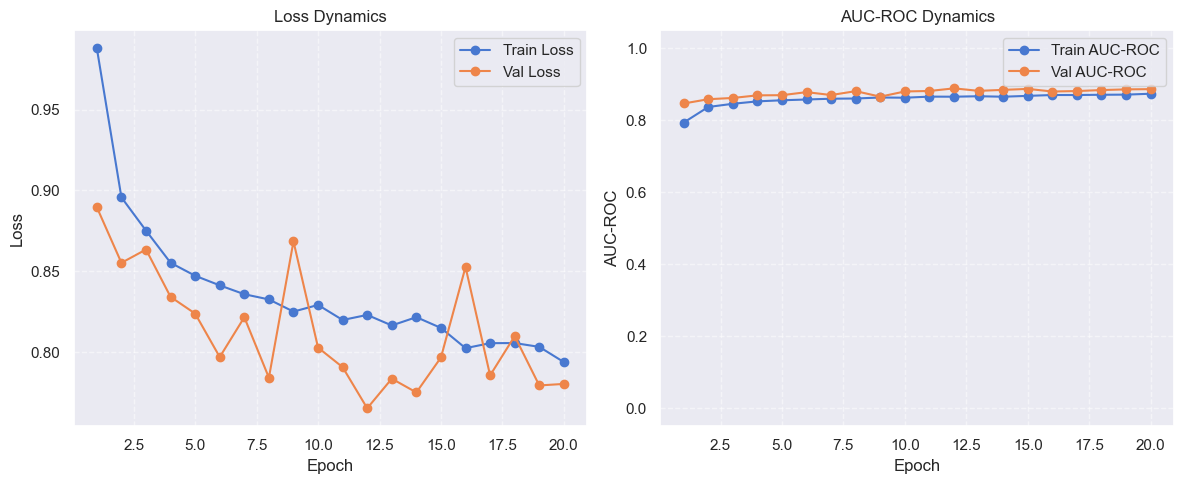

In [ ]:
fit(model, train_loader, val_loader, optimizer, None, criterion, device, num_epochs, out_dir='simple_cnn', use_wandb=True, wandb_project='gp5_pics_only1', wandb_run_name='gp5_pics_only1_run6', wandb_config=wandb_config, plot_fn=plot_metrics)

In [116]:
validation_epoch(model, criterion, test_loader, device)

Valid: 100%|██████████| 204/204 [00:22<00:00,  8.94it/s, loss=0.4283]


{'loss': 0.4282946378645737, 'roc_auc': np.float64(0.8727623972196321)}

In [20]:
summary(model)

Layer (type:depth-idx)                   Param #
Sequential                               --
├─Conv2d: 1-1                            896
├─BatchNorm2d: 1-2                       64
├─GELU: 1-3                              --
├─MaxPool2d: 1-4                         --
├─Conv2d: 1-5                            18,496
├─BatchNorm2d: 1-6                       128
├─GELU: 1-7                              --
├─MaxPool2d: 1-8                         --
├─Conv2d: 1-9                            73,856
├─BatchNorm2d: 1-10                      256
├─GELU: 1-11                             --
├─MaxPool2d: 1-12                        --
├─Conv2d: 1-13                           295,168
├─BatchNorm2d: 1-14                      512
├─GELU: 1-15                             --
├─MaxPool2d: 1-16                        --
├─Conv2d: 1-17                           590,080
├─BatchNorm2d: 1-18                      512
├─GELU: 1-19                             --
├─AdaptiveAvgPool2d: 1-20                --
├─Fl

### Попробуем модель потяжелее

In [21]:
class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.GELU(),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
        )

        if in_ch != out_ch or stride != 1:
            self.skip = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch),
            )
        else:
            self.skip = nn.Identity()

        self.act = nn.PReLU(num_parameters=out_ch)

    def forward(self, x):
        return self.act(self.block(x) + self.skip(x))


class CustomModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.stage1 = self._make_stage(3, 64, num_blocks=2, stride=1)
        self.stage2 = self._make_stage(64, 128, num_blocks=2, stride=2)
        self.stage3 = self._make_stage(128, 256, num_blocks=7, stride=2)
        self.stage4 = self._make_stage(256, 512, num_blocks=9, stride=2)

        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten(),
            nn.Linear(4 * 4 * 512, 512, bias=False),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(512, 128, bias=False),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(128, 1)
        )

        self._init_weights()

    def _make_stage(self, in_ch, out_ch, num_blocks, stride):
        blocks = [ResBlock(in_ch, out_ch, stride=stride)]
        for _ in range(num_blocks - 1):
            blocks.append(ResBlock(out_ch, out_ch, stride=1))
        return nn.Sequential(*blocks)

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d) or isinstance(m, nn.BatchNorm1d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        x = self.fc(x)
        return x

In [ ]:
steps_per_epoch = 365 * 2
num_epochs = 80
warmup_epochs = 3
warmup_steps = steps_per_epoch * warmup_epochs
total_steps = steps_per_epoch * num_epochs

def lr_lambda(step):
    if step < warmup_steps:
        return float(step + 1) / float(warmup_steps)

    progress = float(step - warmup_steps) / float(max(1, total_steps - warmup_steps))
    return 0.5 * (1.0 + np.cos(np.pi * progress))

device = torch.device('cuda')

train_transforms = v2.Compose([
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomVerticalFlip(p=0.5),
    v2.RandomRotation(degrees=90, interpolation=v2.InterpolationMode.BILINEAR, fill=0),
    v2.RandomApply([v2.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10, hue=0.03)], p=0.3),
    v2.RandomApply([v2.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05), interpolation=v2.InterpolationMode.BILINEAR, fill=0)], p=0.3),
    v2.RandomApply([v2.GaussianBlur(kernel_size=3, sigma=(0.1, 0.8))], p=0.1),
    v2.ToImage(),
    v2.ToDtype(torch.float32, True),
    v2.Normalize(train_mean, train_std),
])
train_dataset = ISICDataset('data/images', train_labels, transforms=train_transforms)

test_transforms = v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, True), v2.Normalize(train_mean, train_std)])

test_dataset = ISICDataset('data/images', test_labels, transforms=test_transforms)
val_dataset = ISICDataset('data/images', val_labels, transforms=test_transforms)

n_pos = train_labels["target"].sum()
n_neg = len(train_labels) - n_pos
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32, device=device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

train_loader = data.DataLoader(train_dataset, batch_size=64, num_workers=8, shuffle=True, persistent_workers=True, prefetch_factor=4, pin_memory=True)
test_loader = data.DataLoader(test_dataset, batch_size=128)
val_loader = data.DataLoader(val_dataset, batch_size=128, num_workers=2)

model = CustomModel()

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)
seed_everything(RANDOM_STATE)

33

In [122]:
wandb_config = {
    "task": "melanoma_detection",
    "target": "binary_melanoma_vs_non_melanoma",
    "dataset": "ISIC 2019 + ISIC 2020",
    "metadata": False,
    "image_dir": "data/images",

    "train_size": len(train_labels),
    "val_size": len(val_labels),
    "test_size": len(test_labels),
    "n_pos_train": int(n_pos),
    "n_neg_train": int(n_neg),
    "pos_ratio_train": float(n_pos / len(train_labels)),
    "pos_weight": n_neg / n_pos,

    "image_size": 224,
    "normalization_mean": train_mean.tolist(),
    "normalization_std": train_std.tolist(),

    "augmentations": {
        "random_horizontal_flip": {
            "p": 0.5,
        },
        "random_vertical_flip": {
            "p": 0.5,
        },
        "random_rotation": {
            "degrees": 180,
            "interpolation": "bilinear",
            "fill": 0,
        },
        "color_jitter": {
            "brightness": 0.15,
            "contrast": 0.15,
            "saturation": 0.10,
            "hue": 0.03,
        },
        "gaussian_blur": {
            "p": 0.2,
            "kernel_size": 3,
            "sigma": [0.1, 0.8],
        },
    },

    "train_batch_size": 64,
    "val_batch_size": 128,
    "test_batch_size": 128,
    "train_num_workers": 8,
    "val_num_workers": 2,
    "pin_memory": True,
    "persistent_workers": True,
    "prefetch_factor": 4,

    "model_name": "CustomCNN",
    "model_type": "CNN_from_scratch",
    "pretrained": False,
    "activation": "GELU",
    "normalization": "BatchNorm2d",
    "dropout": 0.3,
    "conv_channels": [32, 64, 128, 256, 256],
    "pooling": "MaxPool2d + AdaptiveAvgPool2d",
    "classifier_hidden_dim": 512 * 4 * 4,
    "output_dim": 1,
    "num_params": sum(p.numel() for p in model.parameters()),
    "num_trainable_params": sum(p.numel() for p in model.parameters() if p.requires_grad),

    "optimizer": "Adam",
    "learning_rate": 1e-4,
    "loss": "BCEWithLogitsLoss",
    "loss_pos_weight": float(pos_weight.detach().cpu().item()),

    "device": str(device),
    "num_epochs": num_epochs,
    "metrics": ["loss", "roc_auc"],
}

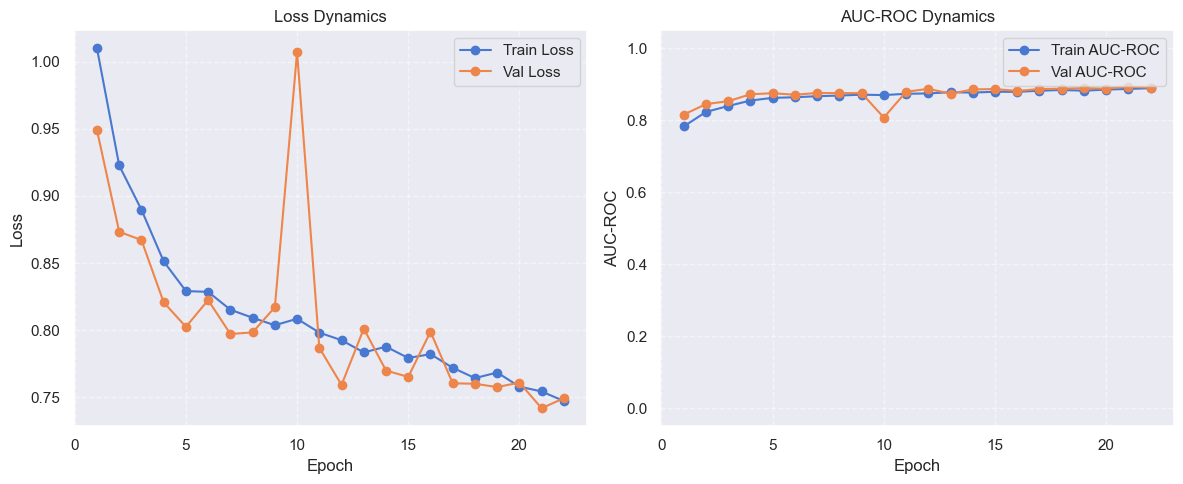

In [ ]:
fit(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    scheduler=scheduler,
    criterion=criterion,
    num_epochs=num_epochs,
    out_dir='custom_model',
    plot_fn=plot_metrics,
    device=device,
    save_every_n_epochs=10,
    wandb_config=wandb_config,
    use_wandb=True,
    wandb_project='gp5_pics_only_custom_model',
    wandb_run_name='gp5_pics_only_custom_model_run1'
)

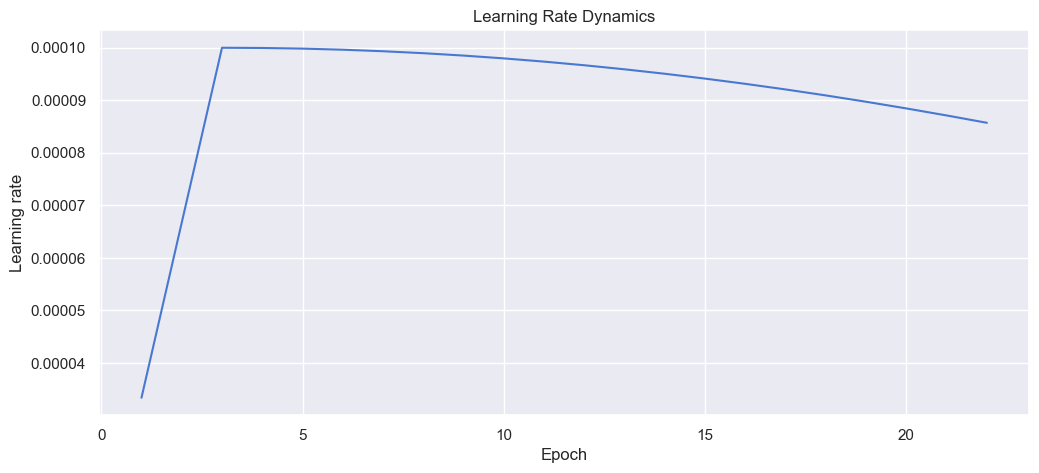

In [ ]:
validation_epoch(model, criterion, test_loader, device)

Valid: 100%|██████████| 55/55 [04:57<00:00,  5.41s/it, loss=0.7418]


{'loss': 0.7417627687048463, 'roc_auc': 0.8932001427877553}

In [ ]:
summary(model)

Layer (type:depth-idx)                   Param #
CustomModel                              --
├─Sequential: 1-1                        --
│    └─ResBlock: 2-1                     --
│    │    └─Sequential: 3-1              38,848
│    │    └─Sequential: 3-2              320
│    │    └─PReLU: 3-3                   64
│    └─ResBlock: 2-2                     --
│    │    └─Sequential: 3-4              73,984
│    │    └─Identity: 3-5                --
│    │    └─PReLU: 3-6                   64
├─Sequential: 1-2                        --
│    └─ResBlock: 2-3                     --
│    │    └─Sequential: 3-7              221,696
│    │    └─Sequential: 3-8              8,448
│    │    └─PReLU: 3-9                   128
│    └─ResBlock: 2-4                     --
│    │    └─Sequential: 3-10             295,424
│    │    └─Identity: 3-11               --
│    │    └─PReLU: 3-12                  128
├─Sequential: 1-3                        --
│    └─ResBlock: 2-5                     --
│  

### Попробуем ResNet-152

In [64]:
from torchvision.models import resnet152, ResNet152_Weights

In [ ]:
model = resnet152(weights=ResNet152_Weights.IMAGENET1K_V2)

for p in model.parameters():
    p.requires_grad = False

model.fc = nn.Sequential(
    nn.Linear(2048, 512),
    nn.ReLU(),
    nn.BatchNorm1d(512),
    nn.Linear(512, 1)
)

for p in model.fc.parameters():
    p.requires_grad = True

device = torch.device('cuda')

train_transforms = v2.Compose([
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomVerticalFlip(p=0.5),
    v2.RandomRotation(degrees=180, interpolation=v2.InterpolationMode.BILINEAR, fill=0),
    v2.RandomApply([v2.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10, hue=0.03)], p=0.1),
    v2.RandomApply([v2.GaussianBlur(kernel_size=3, sigma=(0.1, 0.8))], p=0.1),
    v2.ToImage(),
    v2.ToDtype(torch.float32, True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
train_dataset = ISICDataset('data/images', train_labels, transforms=train_transforms)

test_transforms = v2.Compose([v2.ToDtype(torch.float32, True), v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

test_dataset = ISICDataset('data/images', test_labels, transforms=test_transforms)
val_dataset = ISICDataset('data/images', val_labels, transforms=test_transforms)

n_pos = train_labels["target"].sum()
n_neg = len(train_labels) - n_pos
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32, device=device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

train_loader = data.DataLoader(train_dataset, batch_size=128, num_workers=0, shuffle=True, pin_memory=True)
test_loader = data.DataLoader(test_dataset, batch_size=256)
val_loader = data.DataLoader(val_dataset, batch_size=256, num_workers=0, pin_memory=True)

steps_per_epoch = 365
num_epochs = 20
warmup_epochs = 3
warmup_steps = steps_per_epoch * warmup_epochs
total_steps = steps_per_epoch * num_epochs

def lr_lambda(step):
    if step < warmup_steps:
        return float(step + 1) / float(warmup_steps)

    progress = float(step - warmup_steps) / float(max(1, total_steps - warmup_steps))
    return 0.5 * (1.0 + np.cos(np.pi * progress))

optimizer = torch.optim.AdamW(model.fc.parameters(), lr=0.0005, weight_decay=0.015)
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)


seed_everything(RANDOM_STATE)

33

In [103]:
wandb_config = {
    "task": "melanoma_detection",
    "target": "binary_melanoma_vs_non_melanoma",
    "dataset": "ISIC 2019 + ISIC 2020",
    "metadata": False,
    "image_dir": "data/images",

    "train_size": len(train_labels),
    "val_size": len(val_labels),
    "test_size": len(test_labels),
    "n_pos_train": int(n_pos),
    "n_neg_train": int(n_neg),
    "pos_ratio_train": float(n_pos / len(train_labels)),
    "pos_weight": n_neg / n_pos,

    "image_size": 224,

    "augmentations": {
        "random_horizontal_flip": {
            "p": 0.5,
        },
        "random_vertical_flip": {
            "p": 0.5,
        },
        "random_rotation": {
            "degrees": 180,
            "interpolation": "bilinear",
            "fill": 0,
        },
        "color_jitter": {
            "brightness": 0.15,
            "contrast": 0.15,
            "saturation": 0.10,
            "hue": 0.03,
        },
        "gaussian_blur": {
            "p": 0.2,
            "kernel_size": 3,
            "sigma": [0.1, 0.8],
        },
    },

    "train_batch_size": 128,
    "val_batch_size": 256,
    "test_batch_size": 256,
    "train_num_workers": 0,
    "val_num_workers": 0,
    "pin_memory": True,
    "persistent_workers": True,
    "prefetch_factor": 4,

    "model_name": "ResNet152",
    "model_type": "CNN_fine_tuning",
    "pretrained": True,
    "activation": "RELU",
    "normalization": "BatchNorm2d",
    "dropout": 0.3,
    "classifier_hidden_dim": 2048,
    "output_dim": 1,
    "num_params": sum(p.numel() for p in model.parameters()),
    "num_trainable_params": sum(p.numel() for p in model.parameters() if p.requires_grad),

    "optimizer": "AdamW",
    "learning_rate": 1e-4,
    "loss": "BCEWithLogitsLoss",
    "loss_pos_weight": float(pos_weight.detach().cpu().item()),

    "device": str(device),
    "num_epochs": num_epochs,
    "metrics": ["loss", "roc_auc"],
}

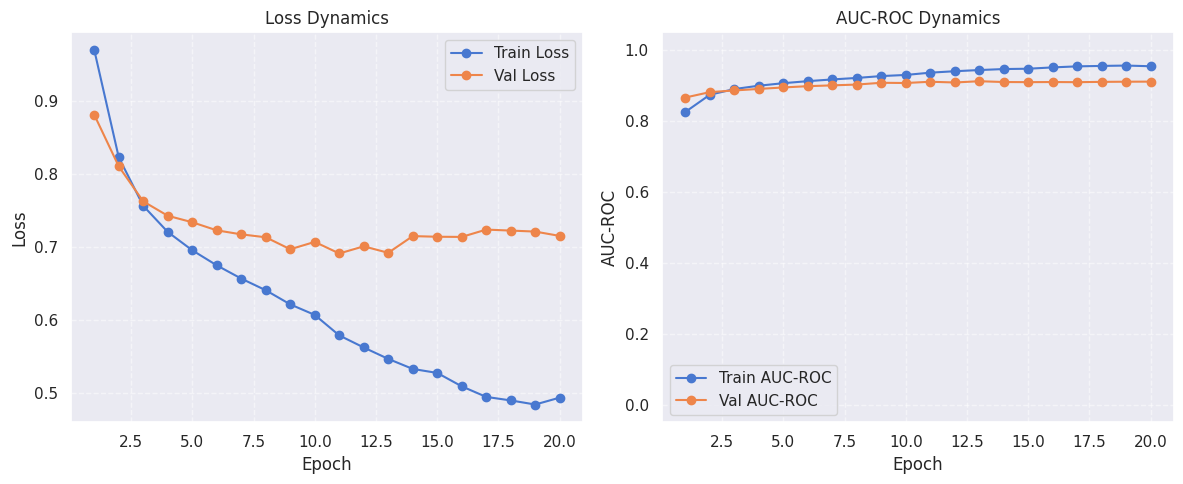

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
lr,▃▆███▇▇▇▆▅▅▄▄▃▂▂▂▁▁▁
train/loss,█▆▅▄▄▄▃▃▃▃▂▂▂▂▂▁▁▁▁▁
train/roc_auc,▁▄▄▅▅▆▆▆▆▇▇▇▇▇██████
val/loss,█▅▄▃▃▂▂▂▁▂▁▁▁▂▂▂▂▂▂▂
val/roc_auc,▁▃▄▅▅▆▆▇▇▇█▇████████
epoch,20
lr,0
train/loss,0.49318
train/roc_auc,0.9543
val/loss,0.71491


{'train_loss': [0.9697804077371341,
  0.8225742111382548,
  0.7561491064040116,
  0.720310893429228,
  0.6952153776056922,
  0.6745586050474434,
  0.6563937872749099,
  0.6403973038555167,
  0.6210291570812388,
  0.6065788022713873,
  0.5784759272576319,
  0.5619174363358501,
  0.5462697016681134,
  0.532510001294866,
  0.52701980823652,
  0.5086471352944699,
  0.49414515042322354,
  0.48933390403005306,
  0.4837011395518835,
  0.4931807734893454],
 'val_loss': [0.881001179419811,
  0.8102273398436933,
  0.762247731997448,
  0.7425381971522101,
  0.7336502219526377,
  0.7225699034641294,
  0.7170525800494179,
  0.7130506351156142,
  0.696639033571643,
  0.7067022430495083,
  0.690832942537006,
  0.7006383603263214,
  0.691734665942015,
  0.7146634259678717,
  0.7137684116085756,
  0.7135431667793009,
  0.7235799902578819,
  0.7222371962940536,
  0.7208499096925431,
  0.7149108190117122],
 'train_roc_auc': [np.float64(0.8252299924386963),
  np.float64(0.8737930701981551),
  np.float64(0

In [104]:
fit(model, train_loader, val_loader, optimizer, scheduler, criterion, device, num_epochs, out_dir='resnet152', use_wandb=True, wandb_project='gp5_pics_only_resnset152', wandb_run_name='gp5_pics_only_resnet152_run02', plot_fn=plot_metrics)

In [33]:
validation_epoch(model, criterion, test_loader, device)

Valid: 100%|██████████| 204/204 [00:38<00:00,  5.25it/s, loss=0.7306]


{'loss': 0.7306002568231551, 'roc_auc': np.float64(0.8972862253115199)}